<a href="https://colab.research.google.com/github/Cami87029i/Inteligencia-Artificial-1/blob/main/Practica1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
from matplotlib import pyplot

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/phoneme.csv'
data = np.loadtxt(url, delimiter=',')
X, y = data[:, :5], data[:,5]
m = y.size

In [4]:
print(m)

5404


In [5]:
display(X[:5])

array([[ 1.24 ,  0.875, -0.205, -0.078,  0.067],
       [ 0.268,  1.352,  1.035, -0.332,  0.217],
       [ 1.567,  0.867,  1.3  ,  1.041,  0.559],
       [ 0.279,  0.99 ,  2.555, -0.738,  0.   ],
       [ 0.307,  1.272,  2.656, -0.946, -0.467]])

In [6]:
X.shape

(5404, 5)

In [7]:
def normalizarCaracteristicas(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma


In [8]:
# llama featureNormalize con los datos cargados
X_norm, mu, sigma = normalizarCaracteristicas(X)

print(X)
print('Media calculada:', mu)
print('Desviacion estandar calculada:', sigma)
print(X_norm)


[[ 1.24   0.875 -0.205 -0.078  0.067]
 [ 0.268  1.352  1.035 -0.332  0.217]
 [ 1.567  0.867  1.3    1.041  0.559]
 ...
 [ 1.031  0.584  1.866  1.532 -0.671]
 [ 0.15   0.933  2.363 -0.742 -0.617]
 [ 0.137  0.714  1.35   0.972 -0.63 ]]
Media calculada: [0.81895725 1.258802   0.76473168 0.3987426  0.0786188 ]
Desviacion estandar calculada: [0.85865361 0.85097861 0.92535076 0.79645733 0.57557096]
[[ 0.49035227 -0.45101251 -1.04796119 -0.59857896 -0.02018657]
 [-0.64165252  0.10951862  0.29207121 -0.91749121  0.24042422]
 [ 0.87118105 -0.46041345  0.57844911  0.80639274  0.83461682]
 ...
 [ 0.24694795 -0.79297175  1.19010906  1.42287272 -1.30239164]
 [-0.77907698 -0.38285569  1.72720269 -1.43227084 -1.20857176]
 [-0.79421696 -0.64020646  0.63248267  0.71975909 -1.23115802]]


In [9]:
def graficarDatos(x, y, xlabel, ylabel):
  fig = pyplot.figure()
  pyplot.plot(x, y, 'ro')
  pyplot.xlabel(xlabel)
  pyplot.ylabel(ylabel)

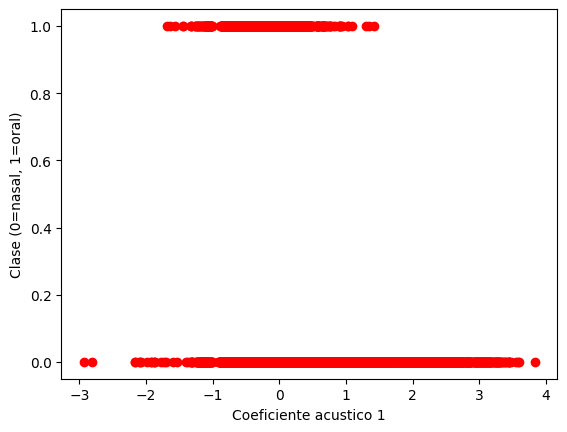

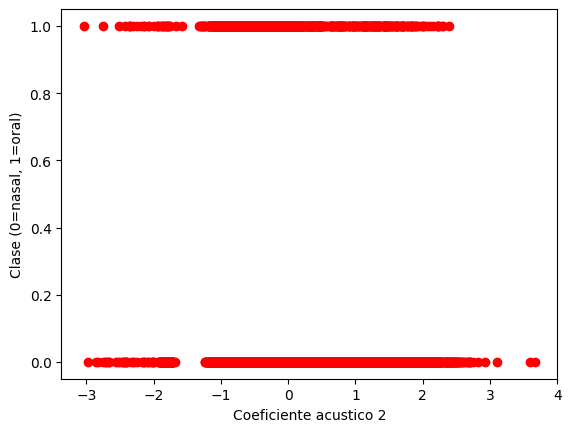

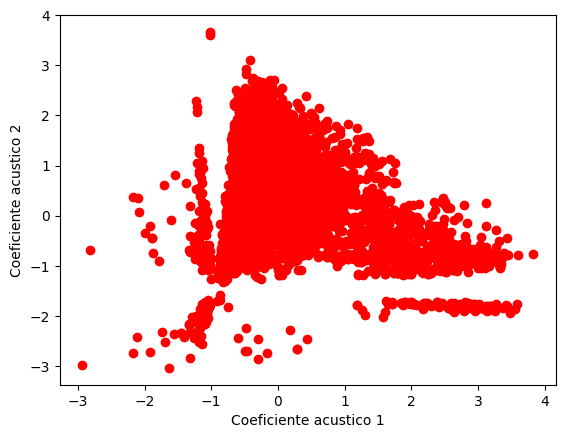

In [10]:
xlabel1 = "Coeficiente acustico 1"
xlabel2 = "Coeficiente acustico 2"
xlabel3 = "Coeficiente acustico 3"
xlabel4 = "Coeficiente acustico 4"
xlabel5 = "Coeficiente acustico 5"
ylabel1 = "Clase (0=nasal, 1=oral)"
graficarDatos(X_norm[:, 0], y, xlabel1, ylabel1)
graficarDatos(X_norm[:, 1], y, xlabel2, ylabel1)
graficarDatos(X_norm[:, 0], X_norm[:, 1], xlabel1, xlabel2)

In [11]:
X_ready = np.concatenate([np.ones((m, 1)), X_norm], axis=1)
# X = np.insert(X, 0, 1, axis=1)
# X.shape


In [12]:
X_ready

array([[ 1.        ,  0.49035227, -0.45101251, -1.04796119, -0.59857896,
        -0.02018657],
       [ 1.        , -0.64165252,  0.10951862,  0.29207121, -0.91749121,
         0.24042422],
       [ 1.        ,  0.87118105, -0.46041345,  0.57844911,  0.80639274,
         0.83461682],
       ...,
       [ 1.        ,  0.24694795, -0.79297175,  1.19010906,  1.42287272,
        -1.30239164],
       [ 1.        , -0.77907698, -0.38285569,  1.72720269, -1.43227084,
        -1.20857176],
       [ 1.        , -0.79421696, -0.64020646,  0.63248267,  0.71975909,
        -1.23115802]])

In [13]:
def sigmoide(z):
  return 1.0 / (1.0 + np.exp(-z))

def calcularCosto(X, y, theta):
  m = y.size
  J = 0
  h = sigmoide(np.dot(X, theta))
  h = np.clip(h, 1e-10, 1 - 1e-10)
  J = -(1 / m) * np.sum(y * np.log(h) + (1 - y) * np.log(1 - h))
  return J

In [14]:
theta = np.zeros(6)
JJ = calcularCosto(X_ready, y, theta)
print(f"con theta:{ theta } se obtiene un costo de: {JJ}")

con theta:[0. 0. 0. 0. 0. 0.] se obtiene un costo de: 0.6931471805599453


In [15]:
def calcularDescensoGradiente(X, y, theta, alpha, numero_iteraciones):
  m = y.shape[0]
  theta = theta.copy()
  J_historico = []

  for i in range(numero_iteraciones):
    h = sigmoide(np.dot(X, theta))
    theta = theta - (alpha / m) * np.dot(X.T, (h - y))
    J_historico.append(calcularCosto(X, y, theta))

  return theta, J_historico

los valores de theta calculados son: [-1.20403592 -0.52368283 -0.34510663  0.62193907  0.62773652  0.31149907]
con un costo de: 0.47078530469044194 


Text(0, 0.5, 'Costo J')

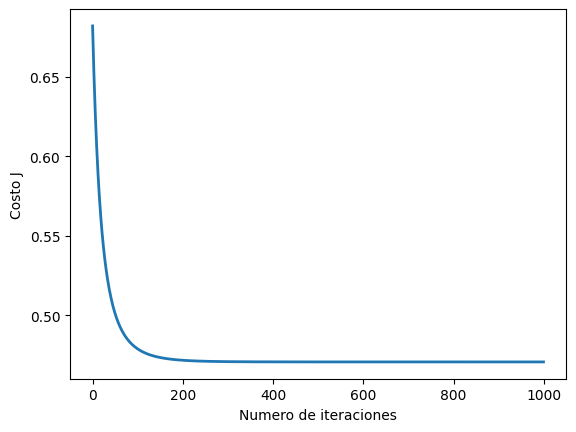

In [16]:
theta = np.zeros(6)

num_ite = 1000
alpha = 0.1

theta, J_historico = calcularDescensoGradiente(X_ready, y, theta, alpha, num_ite)
print(f"los valores de theta calculados son: { theta }")
print(f"con un costo de: { J_historico[-1]} ")

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_historico)), J_historico, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')


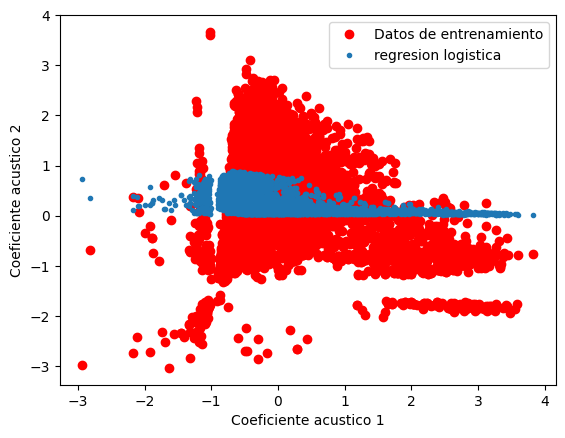

In [17]:
graficarDatos(X_ready[:, 1], X_ready[:, 2], xlabel1, xlabel2)

pyplot.plot(X_ready[:, 1], sigmoide(np.dot(X_ready, theta)), '.')

pyplot.legend(['Datos de entrenamiento', 'regresion logistica'])

In [18]:
# Ejemplo: predecir clase para un nuevo fonema
xp = np.array([1,
               (1.5 - mu[0]) / sigma[0],
               (0.8 - mu[1]) / sigma[1],
               (0.3 - mu[2]) / sigma[2],
               (0.1 - mu[3]) / sigma[3],
               (0.2 - mu[4]) / sigma[4]])
prob = sigmoide(np.dot(xp, theta))
pred = int(prob >= 0.5)
print(f'Probabilidad: {prob:.4f}')
print(f'Clase predicha: {pred}  (0=nasal, 1=oral)')


Probabilidad: 0.1284
Clase predicha: 0  (0=nasal, 1=oral)
